In [1]:
import pandas as pd

# Load the data from the Excel file
file_path = '/content/Occupation_data.xlsx'
df = pd.read_excel(file_path)

# Display basic information about the dataset
df_info = df.info()

# Display basic statistics for the dataset
df_description = df.describe(include='all')

# Display the first few rows of the dataset to understand its structure
df_head = df.head()

# Calculate the number of unique occupations, job zones, and job codes
unique_occupations = df['Occupation'].nunique()
unique_job_zones = df['Job Zone'].nunique()
unique_job_codes = df['Job Code'].nunique()

# Calculate the most common job zones and their counts
job_zone_counts = df['Job Zone'].value_counts()

# Calculate the average number of tasks, technology skills, and work activities per occupation
average_tasks_per_occupation = df['Tasks'].apply(lambda x: len(x.split(', '))).mean()
average_tech_skills_per_occupation = df['Technology Skills'].apply(lambda x: len(x.split(', '))).mean()
average_work_activities_per_occupation = df['Detailed Work Activities'].apply(lambda x: len(x.split(', '))).mean()

# Display results
df_info, df_description, df_head, unique_occupations, unique_job_zones, unique_job_codes, job_zone_counts, average_tasks_per_occupation, average_tech_skills_per_occupation, average_work_activities_per_occupation


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Job Zone                  923 non-null    int64 
 1   Job Code                  923 non-null    object
 2   Occupation                923 non-null    object
 3   Tasks                     923 non-null    object
 4   Technology Skills         923 non-null    object
 5   Detailed Work Activities  923 non-null    object
dtypes: int64(1), object(5)
memory usage: 43.4+ KB


(None,
           Job Zone    Job Code                              Occupation  \
 count   923.000000         923                                     923   
 unique         NaN         923                                     923   
 top            NaN  13-2011.00  Accountants and AuditorsBright Outlook   
 freq           NaN           1                                       1   
 mean      3.189599         NaN                                     NaN   
 std       1.153049         NaN                                     NaN   
 min       1.000000         NaN                                     NaN   
 25%       2.000000         NaN                                     NaN   
 50%       3.000000         NaN                                     NaN   
 75%       4.000000         NaN                                     NaN   
 max       5.000000         NaN                                     NaN   
 
                                                     Tasks  \
 count                       

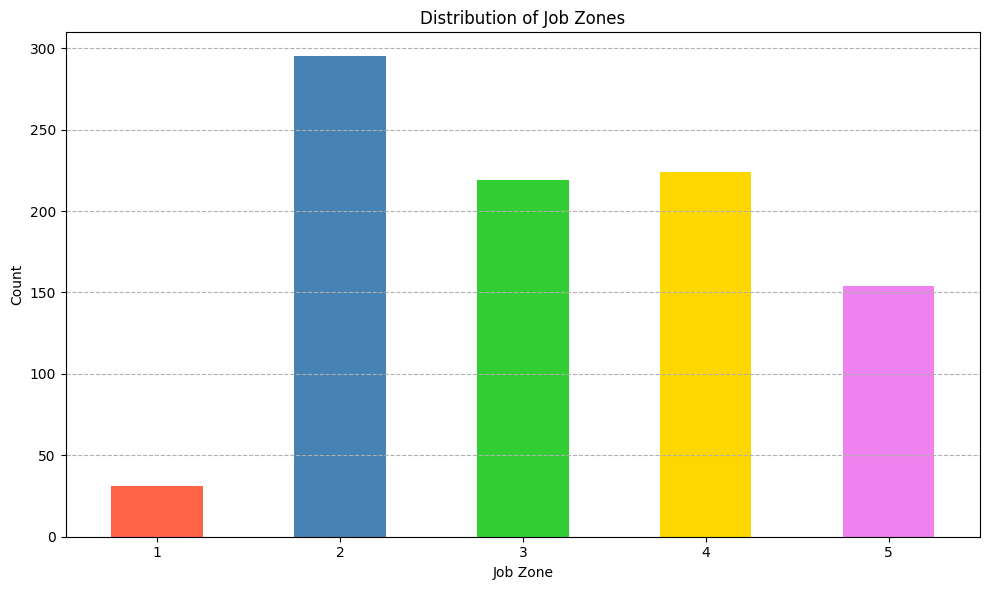

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'job_zone_counts' is a pandas Series containing Job Zones and their counts
# Sorting the job_zone_counts in ascending order of Job Zones
job_zone_counts_sorted = job_zone_counts.sort_index()

# Create a colorful palette
colors = ['#FF6347', '#4682B4', '#32CD32', '#FFD700', '#EE82EE']

# Plot 1: Distribution of Job Zones
plt.figure(figsize=(10, 6))
job_zone_counts_sorted.plot(kind='bar', color=colors)
plt.title('Distribution of Job Zones')
plt.xlabel('Job Zone')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Load the data
file_path = '/content/Occupation_data.xlsx'
df = pd.read_excel(file_path)

# Tokenize tasks, technology skills, and work activities
def tokenize_column(column):
    # Split by ', ' to separate items
    return df[column].str.split(', ').explode().reset_index(drop=True)

# Tokenize each column
tasks_tokens = tokenize_column('Tasks')
tech_skills_tokens = tokenize_column('Technology Skills')
work_activities_tokens = tokenize_column('Detailed Work Activities')

# Combine all tokens into a single DataFrame
all_tokens = pd.concat([
    pd.DataFrame({'Token': tasks_tokens, 'Type': 'Task'}),
    pd.DataFrame({'Token': tech_skills_tokens, 'Type': 'Technology Skill'}),
    pd.DataFrame({'Token': work_activities_tokens, 'Type': 'Work Activity'})
])

# Display the tokenized DataFrame
all_tokens.dropna(inplace=True)  # Remove any NaN values from the list


In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to generate word cloud from tokens
def generate_word_cloud(tokens, title):
    text = ' '.join(tokens)

    wordcloud = WordCloud(
        width=800, height=400,
        background_color='black',
        colormap='rainbow',
        collocations=False
    ).generate(text)

    # Plot the word cloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')

    # Adding the title at the top of the visualization
    plt.text(
        wordcloud.width / 2, -30, title, fontsize=30, color='white',
        ha='center', va='top', weight='bold', bbox=dict(facecolor='black', alpha=0.6, edgecolor='none')
    )

    plt.tight_layout()
    plt.show()



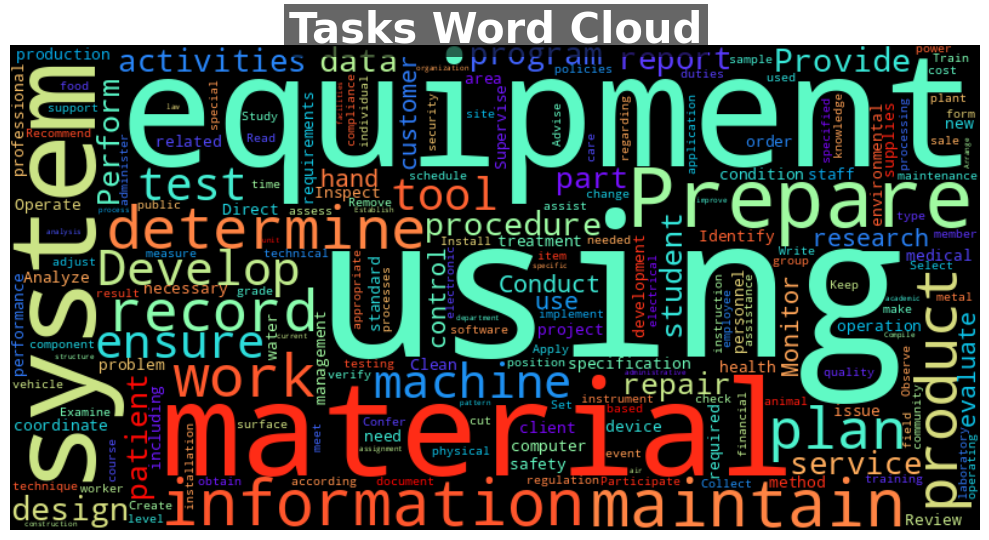

In [5]:
generate_word_cloud(tasks_tokens.dropna(), 'Tasks Word Cloud')

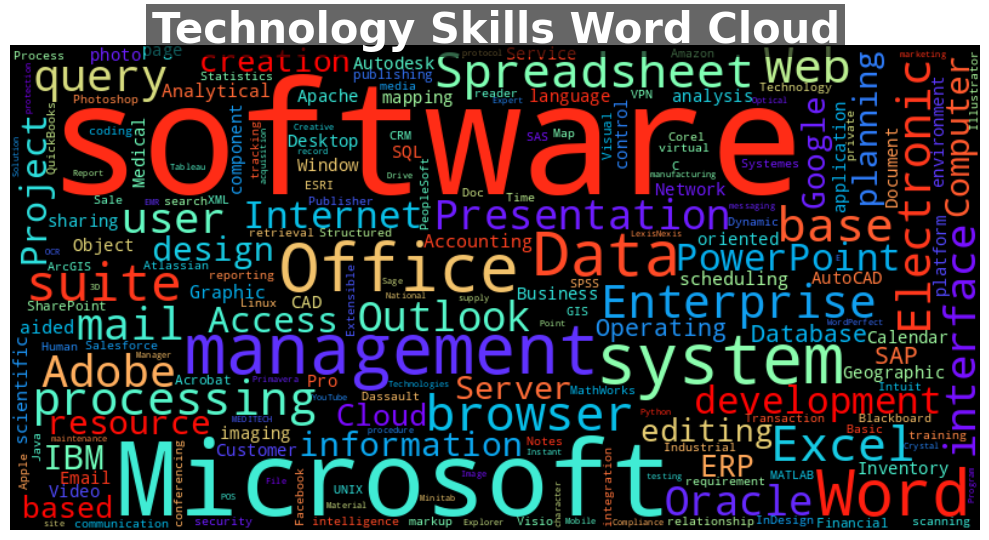

In [6]:
generate_word_cloud(tech_skills_tokens.dropna(), 'Technology Skills Word Cloud')

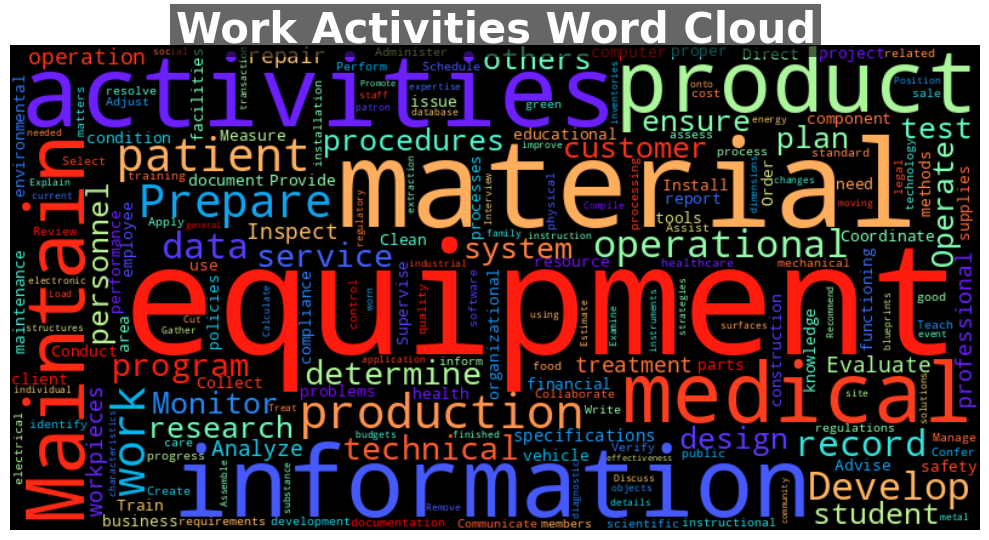

In [7]:
generate_word_cloud(work_activities_tokens.dropna(), 'Work Activities Word Cloud')

In [10]:
from fuzzywuzzy import fuzz

def map_df_dimension(tasks_tokens, tech_skills_tokens):
    # Updated keywords based on word cloud analysis
    categories = {
        'Structured': {
            'keywords': {
                'accounting', 'spreadsheet', 'Excel', 'SQL', 'fields', 'columns', 'reports', 'budgets',
                'relational', 'ERP', 'tableau', 'analytical', 'data analysis', 'databases', 'statistical', 'queries', 'Access'
            },
            'score': 0
        },
        'Unstructured': {
            'keywords': {
                'email', 'document', 'text', 'images', 'files', 'comments', 'photos', 'audio', 'video', 'social media',
                'presentations', 'communication', 'publications', 'scripts', 'media', 'writing', 'marketing', 'advertising'
            },
            'score': 0
        },
        'Semi-structured': {
            'keywords': {
                'JSON', 'XML', 'web scraping', 'API', 'logs', 'metadata', 'tags', 'HTML', 'data feeds', 'structured text',
                'schemas', 'record', 'forms', 'survey', 'questionnaires'
            },
            'score': 0
        }
    }

    combined_tokens = tasks_tokens + tech_skills_tokens

    # Function to calculate the confidence score for a given token list and keywords
    def calculate_confidence_score(token_list, keywords):
        score = 0
        for token in token_list:
            for keyword in keywords:
                match_ratio = fuzz.token_set_ratio(token, keyword)
                if match_ratio > 80:  # Consider matches above a threshold of 80
                    score += match_ratio / 100  # Normalize the score to be between 0 and 1
        return score / len(token_list) if token_list else 0  # Normalize by number of tokens for an average score

    # Calculate confidence scores for each category
    for category in categories:
        categories[category]['score'] = calculate_confidence_score(combined_tokens, categories[category]['keywords'])

    # Find the category with the highest confidence score
    highest_category = max(categories, key=lambda x: categories[x]['score'])
    highest_score = categories[highest_category]['score']

    # Always return the category with the highest confidence score
    return highest_category, highest_score

# Example usage
tasks_tokens_example = ['spreadsheet', 'report', 'data analysis', 'columns']
tech_skills_tokens_example = ['SQL', 'database', 'structured text']

category, score = map_df_dimension(tasks_tokens_example, tech_skills_tokens_example)
print(f"Selected Category: {category} with Confidence Score: {score}")


Selected Category: Structured with Confidence Score: 0.8371428571428571


/usr/local/lib/python3.10/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [11]:
from fuzzywuzzy import fuzz

def map_dq_dimension(tasks_tokens, tech_skills_tokens):
    # Updated keywords based on word cloud analysis and extended domain knowledge
    categories = {
        'Stable': {
            'keywords': {
                'audited', 'certified', 'validated', 'consistent', 'accurate', 'documented', 'structured', 'historical',
                'quality-controlled', 'verified', 'trusted', 'standardized', 'reliable', 'approved', 'fixed', 'persistent',
                'database', 'controlled', 'static', 'archived', 'reviewed', 'financial reports', 'quality', 'approved data',
                'immutable', 'stable data', 'batch-processed', 'enterprise data', 'reference data', 'legacy data', 'golden source',
                'regulatory compliance', 'master data', 'systematic', 'complete'
            },
            'score': 0
        },
        'Unstable': {
            'keywords': {
                'real-time', 'dynamic', 'live data', 'changing', 'streaming', 'unverified', 'on-the-fly', 'volatile',
                'inconsistent', 'sensor data', 'event-driven', 'rapidly changing', 'temporary', 'non-static', 'real-time feeds',
                'transient', 'fluctuating', 'high-frequency', 'dynamic sources', 'live', 'real-time analytics', 'raw data',
                'unstructured feed', 'unscheduled', 'variable', 'new data', 'quick response', 'recently updated'
            },
            'score': 0
        },
        'Semi-stable': {
            'keywords': {
                'semi-stable', 'occasionally updated', 'irregular', 'frequently updated', 'scheduled updates',
                'batch processing with periodic updates', 'time-lagged', 'semi-dynamic', 'quasi-stable', 'periodically refreshed',
                'monthly updates', 'intermittent', 'quasi-real-time', 'partially consistent', 'seasonally updated', 'ad-hoc updates',
                'routine refresh', 'data maintenance', 'controlled updates', 'refresh cycles', 'scheduled refresh', 'bi-monthly'
            },
            'score': 0
        }
    }

    combined_tokens = tasks_tokens + tech_skills_tokens

    # Function to calculate confidence score for a given token list and category keywords
    def calculate_confidence_score(token_list, keywords):
        score = 0
        for token in token_list:
            for keyword in keywords:
                match_ratio = fuzz.token_set_ratio(token, keyword)
                if match_ratio > 80:  # Only consider matches above a certain threshold (80)
                    score += match_ratio / 100  # Normalize score between 0 and 1
        return score / len(token_list) if token_list else 0  # Average score per token

    # Calculate confidence scores for each category
    for category in categories:
        categories[category]['score'] = calculate_confidence_score(combined_tokens, categories[category]['keywords'])

    # Find the category with the highest confidence score
    highest_category = max(categories, key=lambda x: categories[x]['score'])
    highest_score = categories[highest_category]['score']

    # Always select the category with the highest confidence score
    return highest_category, highest_score




In [12]:
import spacy
import pandas as pd

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# Define a function to process the text using NLP and return lemmatized tokens
def process_text(text):
    if pd.isna(text):  # Handle missing values
        return []

    doc = nlp(text.lower())
    return [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
def map_mas_dimensions(row):
    mas_mapping = {}

    # Process the relevant text fields (Tasks and Technology Skills) using NLP
    tasks_tokens = process_text(row['Tasks'])
    tech_skills_tokens = process_text(row['Technology Skills'])

    # Map each MAS dimension separately
    mas_mapping['Data Format'] = map_df_dimension(tasks_tokens, tech_skills_tokens)
    mas_mapping['Data Quality'] = map_dq_dimension(tasks_tokens, tech_skills_tokens)

    return mas_mapping

In [ ]:
# Apply the mapping function to each row in the dataset and store the results
df_mapped = df.apply(map_mas_dimensions, axis=1)

# Convert the mapping into a DataFrame for easy viewing
df_mas = pd.DataFrame(df_mapped.tolist(), index=df.index)

# Combine the original dataset with the MAS mappings
df_combined = pd.concat([df, df_mas], axis=1)

# Save the results to a new Excel file
output_file = 'Occupation_Data_With_MAS_Mappings_Confidence_Score__Nlp_Taxonomy_Tamers.xlsx'
df_combined.to_excel(output_file, index=False)

print("Data has been written to Occupation_Data_With_MAS_Mappings_Nlp_Taxonomy_Tamers.xlsx")


In [15]:

df_mas = pd.DataFrame(df_mapped.tolist(), index=df.index)

# Function to remove the confidence score and keep only the category name
def remove_confidence_score(value):
    if isinstance(value, tuple) and len(value) == 2:
        return value[0]  # Keep only the first element, which is the category name
    return value  # Return value as-is if it's not a tuple

# Apply the function to remove confidence scores in 'Data Format' and 'Data Quality' columns
df_mas['Data Format'] = df_mas['Data Format'].apply(remove_confidence_score)
df_mas['Data Quality'] = df_mas['Data Quality'].apply(remove_confidence_score)

# Combine the original dataset with the MAS mappings
df_combined = pd.concat([df, df_mas], axis=1)

# Save the results to a new Excel file
output_file = 'Occupation_Data.xlsx'
df_combined.to_excel(output_file, index=False)

print("Data has been written to Occupation_Data_With_MAS_Mappings_No_Confidence_Scores.xlsx")


Data has been written to Occupation_Data_With_MAS_Mappings_No_Confidence_Scores.xlsx


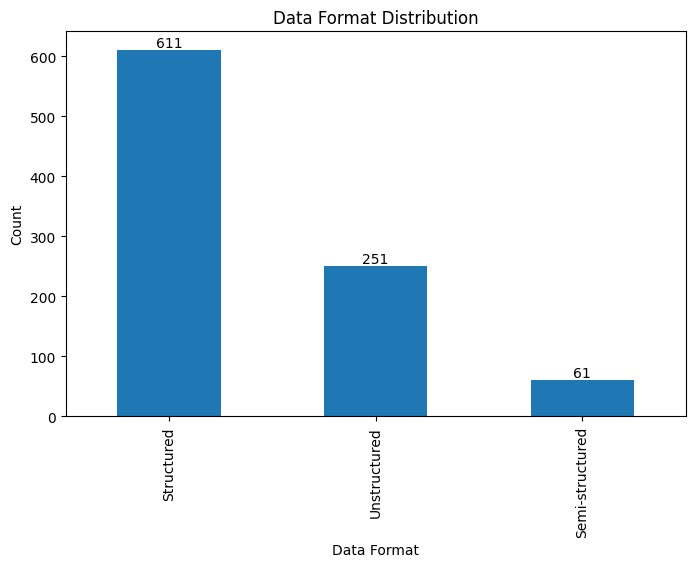

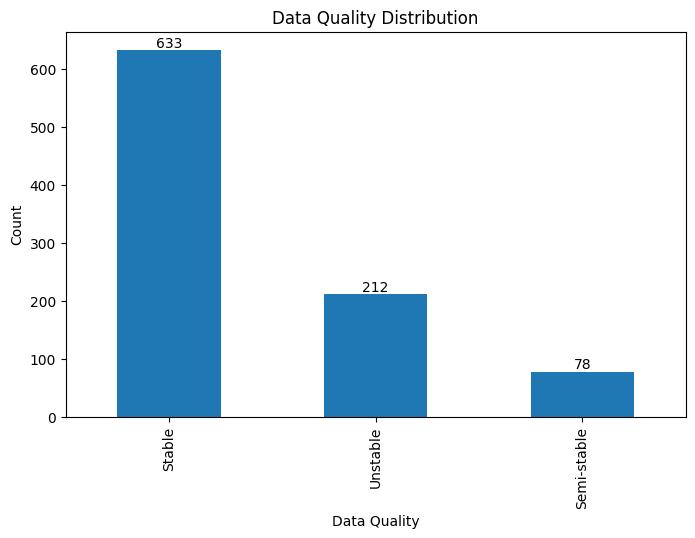

<Figure size 1000x600 with 0 Axes>

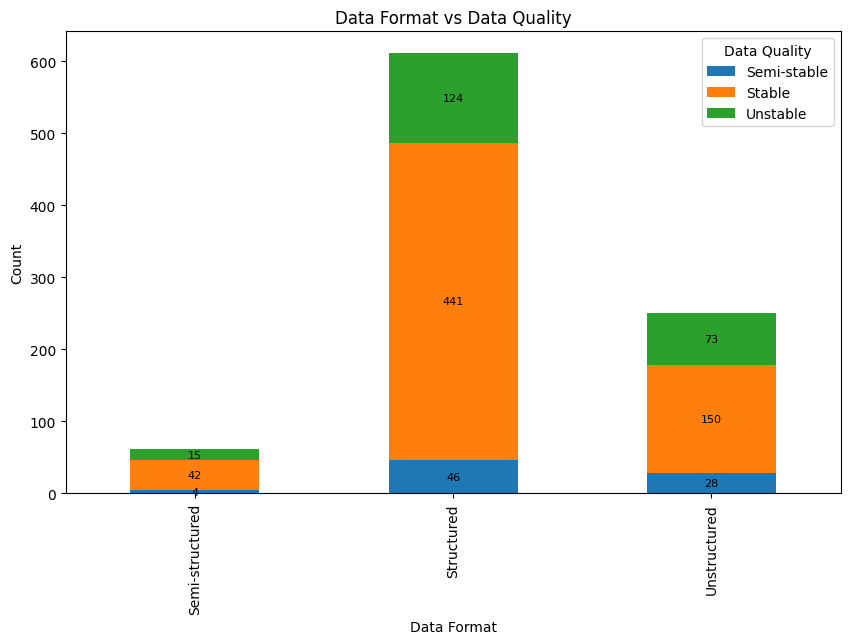

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = '/content/Occupation_Data.xlsx'
excel_data = pd.ExcelFile(file_path)
df = excel_data.parse('Sheet1')  # Adjust sheet name if necessary

# Visualization 1: Data Format Distribution with Numbers
plt.figure(figsize=(8, 5))
data_format_counts = df['Data Format'].value_counts()
data_format_counts.plot(kind='bar', title='Data Format Distribution')
plt.xlabel('Data Format')
plt.ylabel('Count')

# Adding counts on top of bars
for i, count in enumerate(data_format_counts):
    plt.text(i, count + 5, str(count), ha='center')

plt.show()

# Visualization 2: Data Quality Distribution with Numbers
plt.figure(figsize=(8, 5))
data_quality_counts = df['Data Quality'].value_counts()
data_quality_counts.plot(kind='bar', title='Data Quality Distribution')
plt.xlabel('Data Quality')
plt.ylabel('Count')

# Adding counts on top of bars
for i, count in enumerate(data_quality_counts):
    plt.text(i, count + 5, str(count), ha='center')

plt.show()

# Visualization 3: Data Format vs Data Quality with Numbers
plt.figure(figsize=(10, 6))
data_format_quality = pd.crosstab(df['Data Format'], df['Data Quality'])
data_format_quality.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Data Format vs Data Quality')
plt.xlabel('Data Format')
plt.ylabel('Count')
plt.legend(title='Data Quality')

# Adding counts on top of bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='center', fontsize=8)

plt.show()



<Figure size 1000x600 with 0 Axes>

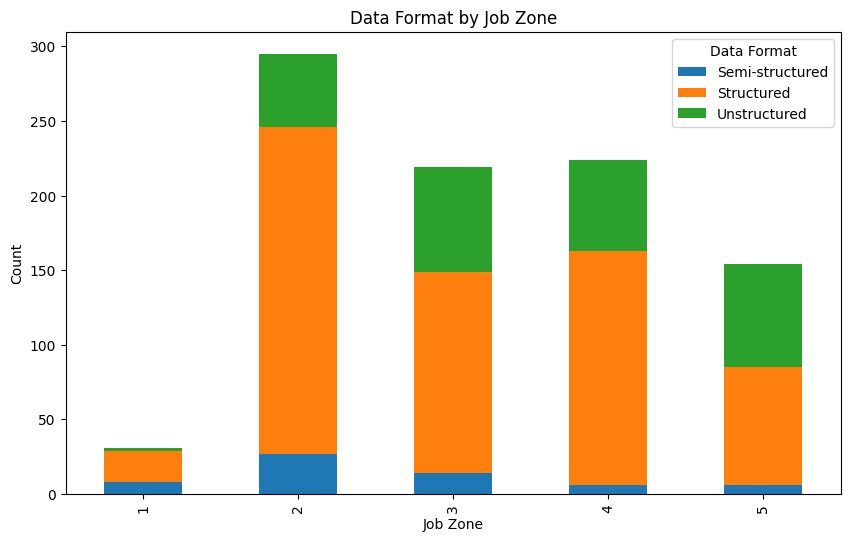

<Figure size 1200x700 with 0 Axes>

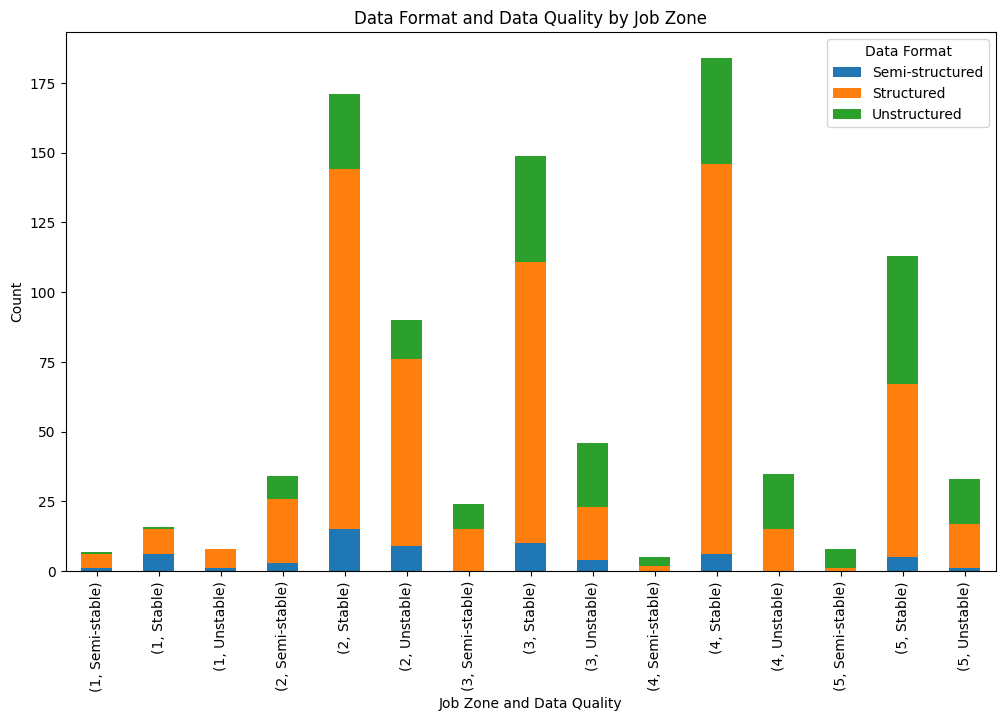

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Visualization 1: Data Format by Job Zone
plt.figure(figsize=(10, 6))
pd.crosstab(df['Job Zone'], df['Data Format']).plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Data Format by Job Zone')
plt.xlabel('Job Zone')
plt.ylabel('Count')
plt.legend(title='Data Format')
plt.show()

# Visualization 2: Data Format and Data Quality by Job Zone
plt.figure(figsize=(12, 7))
pd.crosstab([df['Job Zone'], df['Data Quality']], df['Data Format']).plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Data Format and Data Quality by Job Zone')
plt.xlabel('Job Zone and Data Quality')
plt.ylabel('Count')
plt.legend(title='Data Format')
plt.show()


<Figure size 1000x600 with 0 Axes>

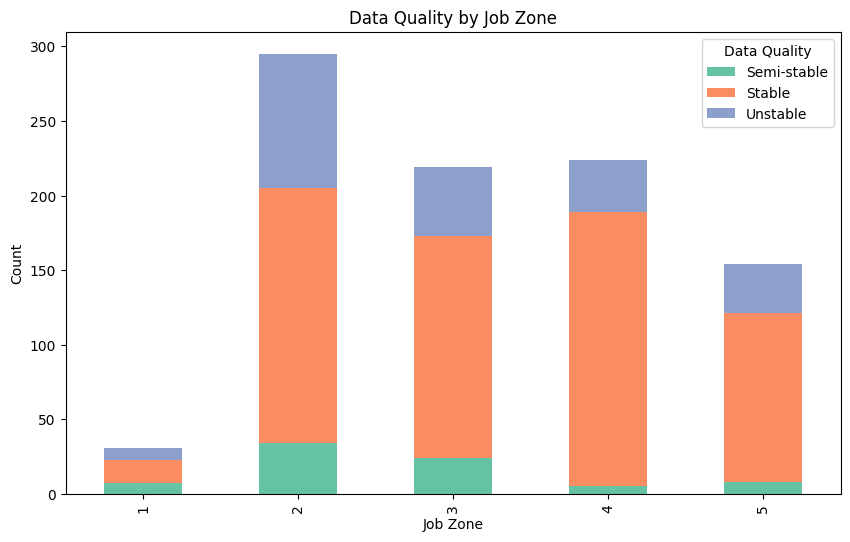

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Define colors for each data quality level
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']  # Add or adjust colors as needed

# Visualization: Data Quality by Job Zone with Custom Colors
plt.figure(figsize=(10, 6))
pd.crosstab(df['Job Zone'], df['Data Quality']).plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Data Quality by Job Zone')
plt.xlabel('Job Zone')
plt.ylabel('Count')
plt.legend(title='Data Quality')
plt.show()
